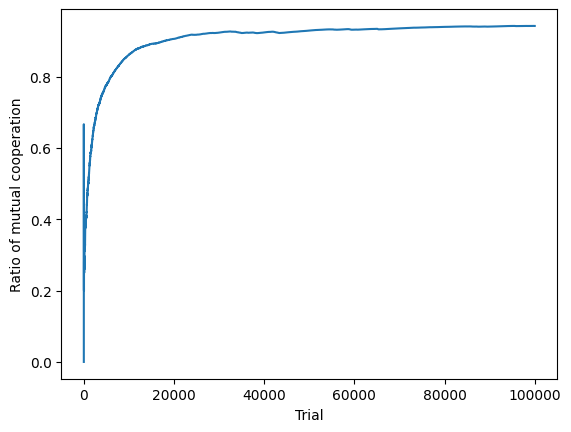

In [15]:
# % The Selfish Algorithm (SA)
# Korosh Mahmoodi 111618
# Cite: Mahmoodi, Korosh, Bruce J. West, and Cleotilde Gonzalez. "Selfish algorithm and emergence of collective intelligence." Journal of Complex Networks 8.3 (2020): cnaa019.

# In SA, there are three decisions for each agent to make:
# Connect or not-Connect
# Defect or Cooperate
# not-Trust or Trsut
# For each decision, there is a moving threshold that divides the interval [0 1] into two parts, P and 1-P, where P is the propensity of the corresponding decision

import numpy as np
import matplotlib.pyplot as plt

def update_sa(pi0, decision, pay, pay_before, chi):
    if decision == 2: # Decision (Cooperated, Trusted, or not-Connected/Played )
        dp = -1 * chi
    else:
        dp = chi

    if pay == pay_before:
        aa = pi0
    else:
        aa = pi0 + dp * (pay - pay_before) / (abs(pay) + abs(pay_before))

    # Boundary condition
    if aa < 0:
        aa = 1e-2
    if aa > 1:
        aa = 1 - 1e-2

    return aa

# Simulation parameters
Trial = int(1e5) # Simulaton length
Size = 10 # Number of the agents

# Constant relating payoff to the change of the propensity/probability of
Chi_Connection = 0.1 # SAC mechanism (connect/play decision)
Chi_RL = 0.1 # SAL mechanism (Cooperation or Defection decision)
Chi_Trust = 0.1 # SAT mechanism (trust decision)
# You can deactivate SAT, SAC, or both mechanisms by setting the corresponding Chi constant(s) to zero (for deactivating SAT must set its initial condition to zero)

# Prisoner's Dilema game's payoffs
s = 0 # s is the payoff of the cooperator agent if another agent defected
p = 0 # p is the payoff of the agents if both defected
tt = 0.9 # (1+ tt) is the payoff of the defector agent if the other agent cooperated (tt < s + 1)
Cost = 0 # cost of cooperation

Ratio_CC = np.zeros(Trial) # Ration of mutual cooperation
CC = 0

Out1 = np.zeros(Size) # Previous payoff
Out2 = np.zeros(Size) # Current payoff

D_C_decision = np.random.choice([1, 2], size=Size) # D (defection) as 1 and C (cooperation) as 2

Connection = np.ones((Size, Size)) # Tendensy of the agents to connect/play
P_RL = np.full((Size, Size), 0.5) # P_RL and (1-P_RL) are the propensity of decison D and C, respectively
P_Trust = np.full((Size, Size), 0.5) # P_Trust and (1-P_Trust) are the propensity of decison "not to trust" and "trust" the decison of another agent, respectively

# Initial conditions
for jjj in range(1, Size + 1):
    r = np.random.rand()
    D_C_decision[jjj - 1] = 1 if r < 0.5 else 2 # 1 as defect (D) decision and 2 as cooperation (C) decision

for jjj in range(1, Size + 1):
    for iii in range(1, Size + 1):
        if iii != jjj:
            P_RL[jjj - 1, iii - 1] = 0.5
            P_Trust[jjj - 1, iii - 1] = 0.5
            Connection[jjj - 1, iii - 1] = 1

for ti in range(1, Trial):

  # Randomly selecting two agents to connect/play
    m = np.random.randint(1, Size + 1)
    n = np.random.randint(1, Size + 1)

    while m == n:
        n = np.random.randint(1, Size + 1)

    Suum1 = np.cumsum(Connection[m - 1, :])
    P1_Connection = Connection[m - 1, n - 1] / Suum1[-1] # Propensity of agent m to connect/play with agent n

    Suum2 = np.cumsum(Connection[n - 1, :])
    P2_Connection = Connection[n - 1, m - 1] / Suum2[-1]

    r1, r2 = np.random.rand(), np.random.rand()

    while r1 > P1_Connection or r2 > P2_Connection: # If the two agents decided not to connect/play, two other agents get selectd
        m = np.random.randint(1, Size + 1)
        n = np.random.randint(1, Size + 1)

        while m == n:
            n = np.random.randint(1, Size + 1)

        Suum1 = np.cumsum(Connection[m - 1, :])
        P1_Connection = Connection[m - 1, n - 1] / Suum1[-1]

        Suum2 = np.cumsum(Connection[n - 1, :])
        P2_Connection = Connection[n - 1, m - 1] / Suum2[-1]

        r1, r2 = np.random.rand(), np.random.rand()

 # Decision of C or D
    if np.random.rand() > P_RL[m - 1, n - 1]:
        D_C_decision[m - 1] = 2
    else:
        D_C_decision[m - 1] = 1

    if np.random.rand() > P_RL[n - 1, m - 1]:
        D_C_decision[n - 1] = 2
    else:
        D_C_decision[n - 1] = 1

 #  Decision to trust or not the decision of the other agent
    D_C_m = D_C_decision[m - 1]
    D_C_n = D_C_decision[n - 1]

    Trustm = 1
    if np.random.rand() > P_Trust[m - 1, n - 1]:
        Trustm = 2
        D_C_decision[m - 1] = D_C_n

    Trustn = 1
    if np.random.rand() > P_Trust[n - 1, m - 1]:
        Trustn = 2
        D_C_decision[n - 1] = D_C_m

  # Payoffs from the Prisoner's Dilemma game
    ggn = 1 if D_C_decision[m - 1] == 2 else 0
    ggm = 1 if D_C_decision[n - 1] == 2 else 0

    if D_C_decision[m - 1] == 2:
        Out2[m - 1] = ggm * (1 - Cost) + (1 - ggm) * (-s)
    else:
        Out2[m - 1] = ggm * (1 + tt) + (1 - ggm) * (p)

    if D_C_decision[n - 1] == 2:
        Out2[n - 1] = ggn * (1 - Cost) + (1 - ggn) * (-s)
    else:
        Out2[n - 1] = ggn * (1 + tt) + (1 - ggn) * (p)

    #   Updating the thresholds
    Connection[m - 1, n - 1] = update_sa(Connection[m - 1, n - 1], 1, Out2[m - 1], Out1[m - 1], Chi_Connection)
    Connection[n - 1, m - 1] = update_sa(Connection[n - 1, m - 1], 1, Out2[n - 1], Out1[n - 1], Chi_Connection)

    if Trustm == 1: # Only update P_RL if the agent didn't Trust
        P_RL[m - 1, n - 1] = update_sa(P_RL[m - 1, n - 1], D_C_decision[m - 1], Out2[m - 1], Out1[m - 1], Chi_RL)
    if Trustn == 1:
        P_RL[n - 1, m - 1] = update_sa(P_RL[n - 1, m - 1], D_C_decision[n - 1], Out2[n - 1], Out1[n - 1], Chi_RL)

    P_Trust[m - 1, n - 1] = update_sa(P_Trust[m - 1, n - 1], Trustm, Out2[m - 1], Out1[m - 1], Chi_Trust)
    P_Trust[n - 1, m - 1] = update_sa(P_Trust[n - 1, m - 1], Trustn, Out2[n - 1], Out1[n - 1], Chi_Trust)

    Out1[m - 1] = Out2[m - 1]
    Out1[n - 1] = Out2[n - 1]

    if D_C_decision[m - 1] == 2 and D_C_decision[n - 1] == 2:
        CC += 1
    Ratio_CC[ti] = CC / (ti + 1)

plt.plot(Ratio_CC)
plt.xlabel('Trial')
plt.ylabel('Ratio of mutual cooperation')
plt.show()
